<a href="https://colab.research.google.com/github/mfernandaazambuja12-cyber/CEP_2026/blob/main/MVP_CEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Previsão de Falha de Máquina com CEP e Machine Learning
## Dataset: AI4I 2020 Predictive Maintenance (Kaggle)
**Autor:** Maria Fernanda Oliveira Azambuja

**Data:** 22 de Abril de 2026  

**Tipo:** Classificação Binária  


### Objetivo
Desenvolver um modelo preditivo para detectar falhas em máquinas industriais,
integrando Controle Estatístico de Processos (CEP) com Machine Learning.


In [ ]:
# ========================================
# ETAPA 0 — INSTALAÇÃO E CONFIGURAÇÃO
# ========================================

# Instalar bibliotecas (se necessário no Colab)
!pip install xgboost imbalanced-learn -q

# Imports principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# Reprodutibilidade — SEEDS FIXOS
import random
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print('Ambiente configurado com sucesso!')
print(f'NumPy: {np.__version__} | Pandas: {pd.__version__}')


Ambiente configurado com sucesso!
NumPy: 2.0.2 | Pandas: 2.2.2


## Etapa 1: Dataset e Fontes

**Fonte:** Kaggle — AI4I 2020 Predictive Maintenance Dataset

**URL:** https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020


O dataset contém 10.000 registros de sensores de máquinas industriais (tipo CNC),
com 6 features de processo e variável-alvo binária indicando falha (1) ou não (0).

**Variáveis:**
- Air temperature [K]: Temperatura do ar
- Process temperature [K]: Temperatura do processo
- Rotational speed [rpm]: Velocidade de rotação
- Torque [Nm]: Torque aplicado
- Tool wear [min]: Desgaste da ferramenta
- Type: Qualidade do produto (L=Low, M=Medium, H=High)
- Machine failure: Target (0 = OK, 1 = Falha)

In [ ]:
# ========================================
# ETAPA 1 — CARREGAMENTO DOS DADOS
# ========================================

import kagglehub

# Download latest version
path = kagglehub.dataset_download("stephanmatzka/predictive-maintenance-dataset-ai4i-2020")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'predictive-maintenance-dataset-ai4i-2020' dataset.
Path to dataset files: /kaggle/input/predictive-maintenance-dataset-ai4i-2020


In [ ]:
from google.colab import files
# uploaded = files.upload()  # Selecione o kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d stephanmatzka/predictive-maintenance-dataset-ai4i-2020
# !unzip predictive-maintenance-dataset-ai4i-2020.zip
df = pd.read_csv('ai4i2020.csv')

print(f'Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head()

Dataset carregado: 10000 linhas x 14 colunas


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


=== DISTRIBUIÇÃO DE MACHINE FAILURE ===
Machine failure
0    9661
1     339
Name: count, dtype: int64

Proporção de falhas: 3.39%


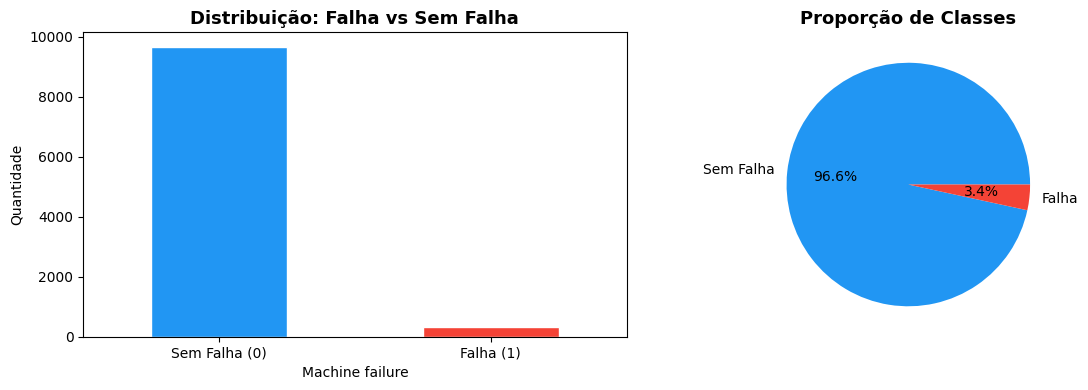

Observação: Dataset fortemente desbalanceado — estratégia de balanceamento necessária!


In [ ]:
# Distribuição do target
print('=== DISTRIBUIÇÃO DE MACHINE FAILURE ===')
print(df['Machine failure'].value_counts())
print(f"\nProporção de falhas: {df['Machine failure'].mean()*100:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
df['Machine failure'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#2196F3','#F44336'], edgecolor='white')
axes[0].set_title('Distribuição: Falha vs Sem Falha', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Sem Falha (0)', 'Falha (1)'], rotation=0)
axes[0].set_ylabel('Quantidade')

# Pizza
df['Machine failure'].value_counts().plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['#2196F3','#F44336'],
    labels=['Sem Falha', 'Falha'])
axes[1].set_title('Proporção de Classes', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('distribuicao_target.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observação: Dataset fortemente desbalanceado — estratégia de balanceamento necessária!')

## Etapa 2: Análise Exploratória de Dados (EDA)

Objetivo: compreender a distribuição das variáveis, identificar padrões,
correlações e possíveis problemas nos dados antes da modelagem.

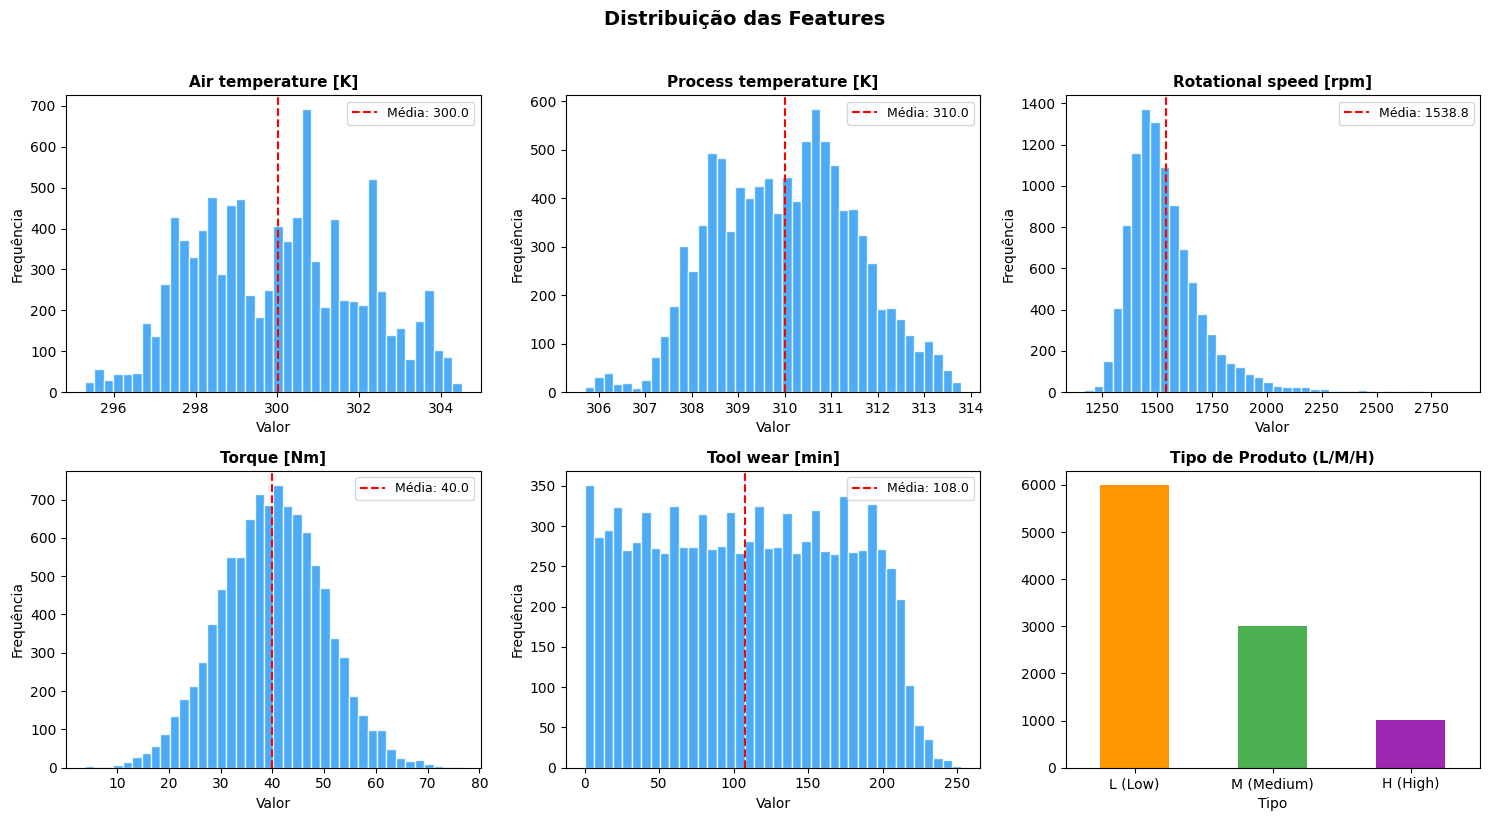

In [ ]:
# Distribuição das features numéricas
numeric_cols = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color='#2196F3', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')
    # Adicionar média
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Média: {df[col].mean():.1f}')
    axes[i].legend(fontsize=9)

# Distribuição do tipo de produto
df['Type'].value_counts().plot(kind='bar', ax=axes[5], color=['#FF9800','#4CAF50','#9C27B0'])
axes[5].set_title('Tipo de Produto (L/M/H)', fontsize=11, fontweight='bold')
axes[5].set_xlabel('Tipo')
axes[5].set_xticklabels(['L (Low)','M (Medium)','H (High)'], rotation=0)

plt.suptitle('Distribuição das Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribuicao_features.png', dpi=150, bbox_inches='tight')
plt.show()

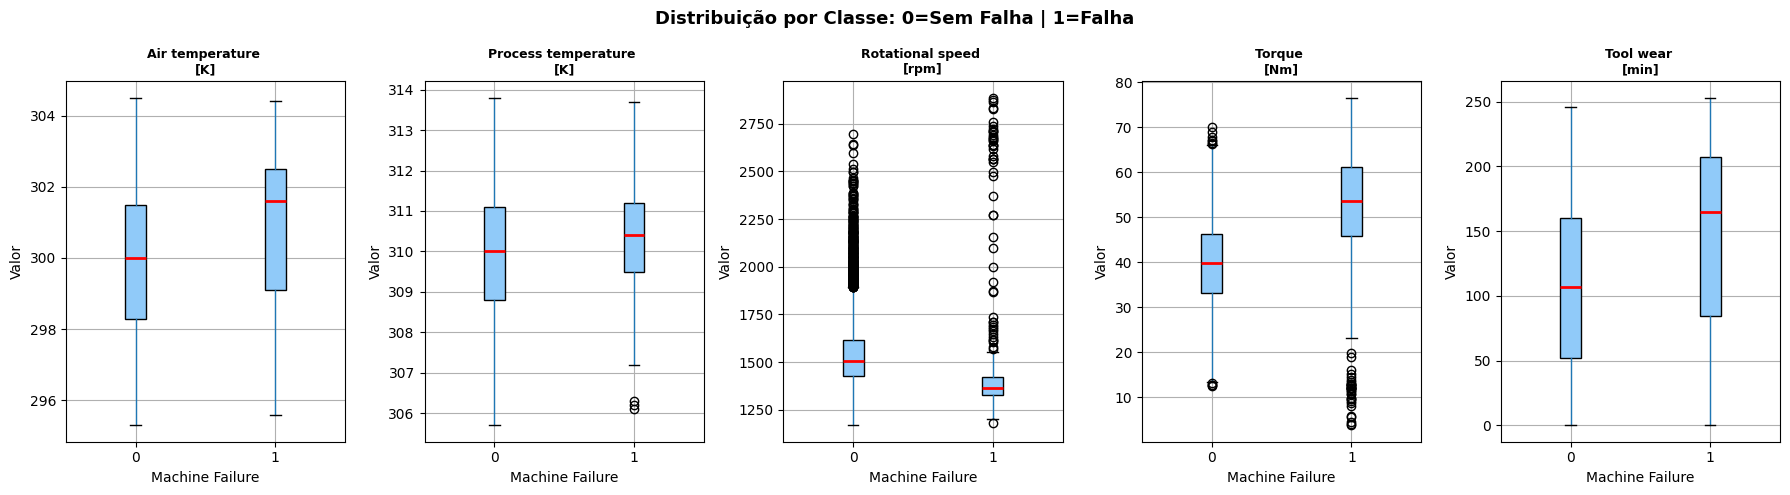

=== MÉDIAS POR CLASSE ===
                 Air temperature [K]  Process temperature [K]  \
Machine failure                                                 
0                             299.97                   310.00   
1                             300.89                   310.29   

                 Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
Machine failure                                                        
0                               1540.26        39.63           106.69  
1                               1496.49        50.17           143.78  


In [ ]:
# Boxplots por classe
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='Machine failure', ax=axes[i],
               patch_artist=True,
               boxprops=dict(facecolor='#90CAF9'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col.replace('[', '\n['), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Machine Failure')
    axes[i].set_ylabel('Valor')

plt.suptitle('Distribuição por Classe: 0=Sem Falha | 1=Falha', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_classe.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela de médias por classe
print('=== MÉDIAS POR CLASSE ===')
print(df.groupby('Machine failure')[numeric_cols].mean().round(2))

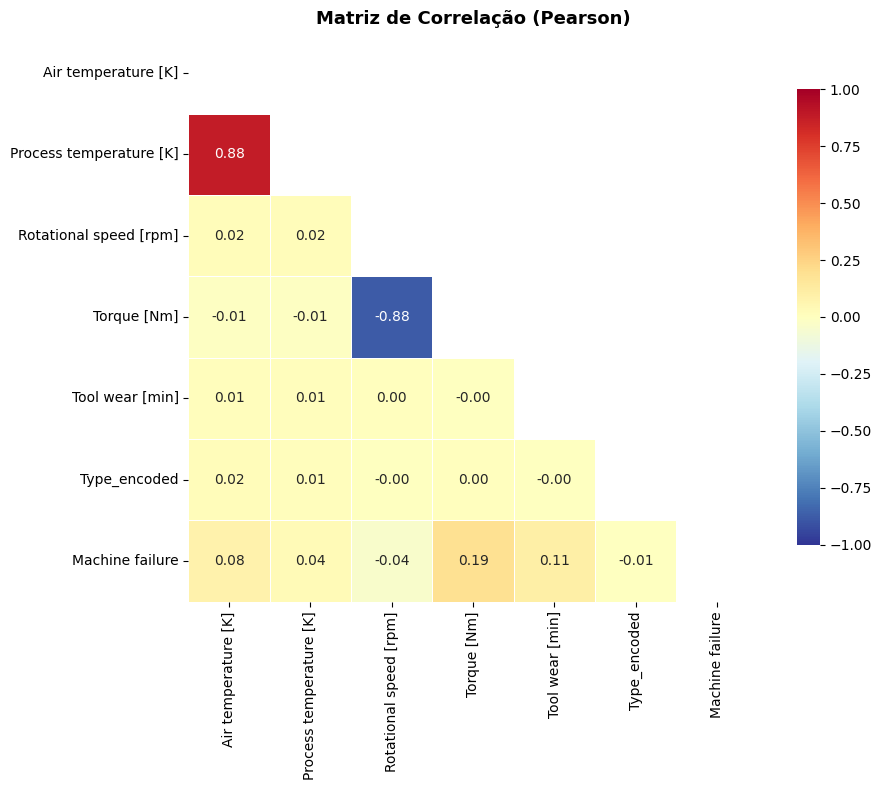

=== CORRELAÇÕES COM MACHINE FAILURE ===
Torque [Nm]                0.1913
Tool wear [min]            0.1054
Air temperature [K]        0.0826
Process temperature [K]    0.0359
Type_encoded              -0.0052
Rotational speed [rpm]    -0.0442
Name: Machine failure, dtype: float64


In [ ]:
# Codificar Type para correlação
df_corr = df.copy()
le = LabelEncoder()
df_corr['Type_encoded'] = le.fit_transform(df_corr['Type'])

corr_cols = numeric_cols + ['Type_encoded', 'Machine failure']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação (Pearson)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlações com o target
print('=== CORRELAÇÕES COM MACHINE FAILURE ===')
corr_target = corr_matrix['Machine failure'].drop('Machine failure').sort_values(ascending=False)
print(corr_target.round(4))

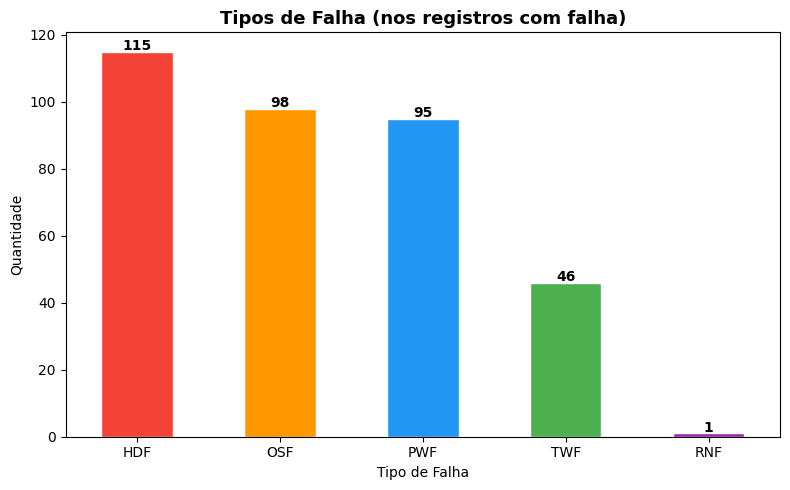

HDF    115
OSF     98
PWF     95
TWF     46
RNF      1
dtype: int64


In [ ]:
# Análise dos tipos de falha (apenas onde falhou)
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Verificar se as colunas existem no dataset
available_failure_cols = [c for c in failure_cols if c in df.columns]

if available_failure_cols:
    falhas_df = df[df['Machine failure'] == 1]
    falha_counts = falhas_df[available_failure_cols].sum().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    falha_counts.plot(kind='bar', color=['#F44336','#FF9800','#2196F3','#4CAF50','#9C27B0'],
                      edgecolor='white')
    plt.title('Tipos de Falha (nos registros com falha)', fontsize=13, fontweight='bold')
    plt.xlabel('Tipo de Falha')
    plt.ylabel('Quantidade')
    plt.xticks(rotation=0)
    for i, v in enumerate(falha_counts):
        plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('tipos_falha.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(falha_counts)
else:
    print('Colunas de subtipo não encontradas. Verifique o nome das colunas no seu CSV.')
    print('Colunas disponíveis:', df.columns.tolist())

## Etapa 3: Controle Estatístico de Processos (CEP)

O CEP é uma metodologia que usa métodos estatísticos para monitorar e controlar
processos produtivos. Aqui aplicamos:

1. **Cartas de Controle X-barra e R** para Air temperature e Torque
2. **Índices de Capacidade Cp, Cpk, Pp, Ppk** para avaliar se o processo
   atende às especificações de qualidade

**Subgrupos:** n = 5 (padrão industrial)
**Constantes para n=5:** A2 = 0.577, D3 = 0, D4 = 2.114

=== CARTA DE CONTROLE: Air temperature [K] ===


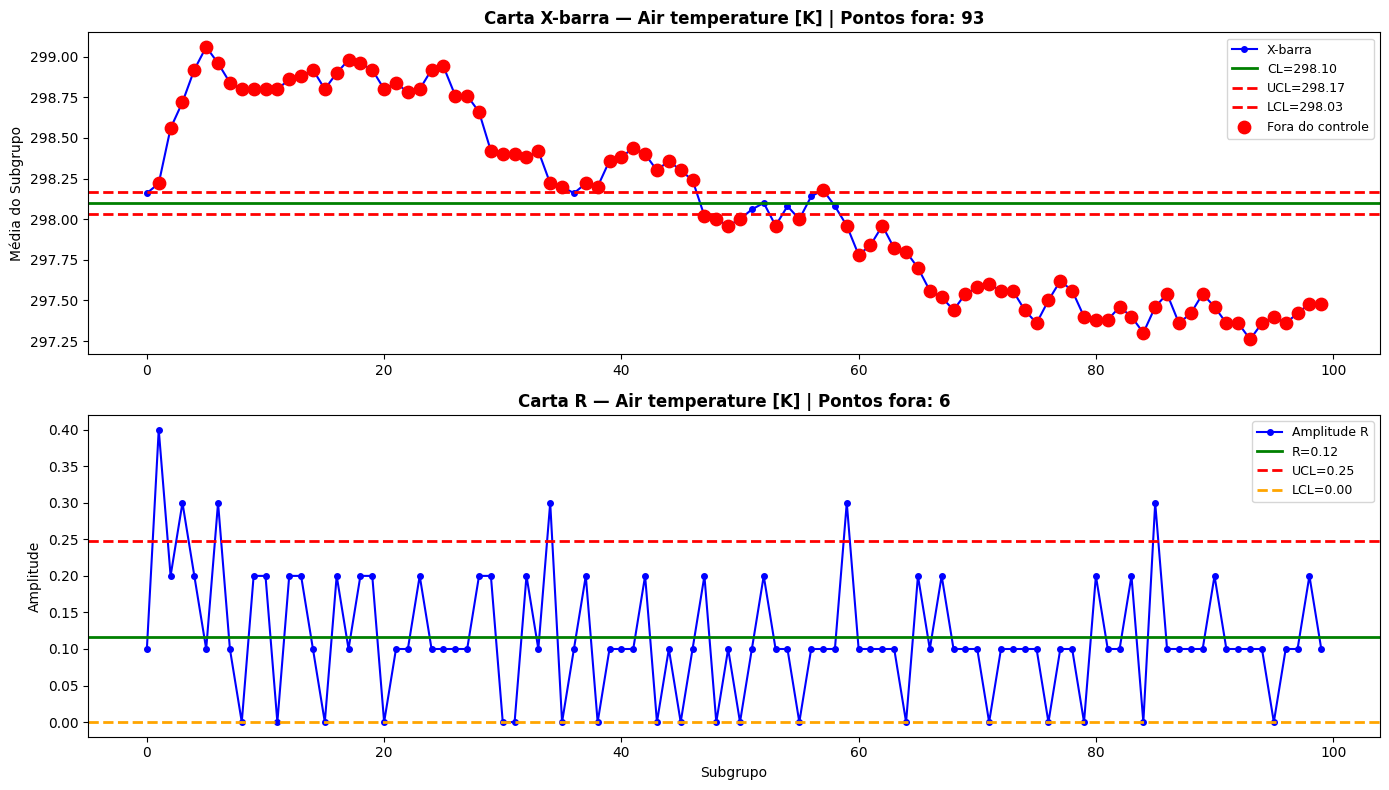

X̄=298.10, UCL=298.17, LCL=298.03
Pontos fora de controle (X-barra): 93


In [ ]:
# ========================================
# ETAPA 3 — CONTROLE ESTATÍSTICO (CEP)
# ========================================

def carta_controle_xbarra_r(data, variavel, n=5, title=''):
    """Gera cartas X-barra e R para uma variável"""
    # Constantes para n=5
    A2, D3, D4 = 0.577, 0, 2.114

    # Criar subgrupos
    total = len(data)
    n_subgroups = total // n
    data_trim = data[:n_subgroups * n]
    subgroups = data_trim.values.reshape(n_subgroups, n)

    # Usar apenas 100 subgrupos para visualização
    subgroups = subgroups[:100]

    # Calcular médias e amplitudes
    x_bars = subgroups.mean(axis=1)
    ranges = subgroups.max(axis=1) - subgroups.min(axis=1)

    # Linhas centrais
    X_bar = x_bars.mean()
    R_bar = ranges.mean()

    # Limites X-barra
    UCL_x = X_bar + A2 * R_bar
    LCL_x = X_bar - A2 * R_bar

    # Limites R
    UCL_r = D4 * R_bar
    LCL_r = D3 * R_bar

    # Pontos fora de controle
    fora_x = np.sum((x_bars > UCL_x) | (x_bars < LCL_x))
    fora_r = np.sum((ranges > UCL_r) | (ranges < LCL_r))

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

    # Carta X-barra
    ax1.plot(x_bars, 'b-o', markersize=4, label='X-barra')
    ax1.axhline(X_bar, color='green', lw=2, label=f'CL={X_bar:.2f}')
    ax1.axhline(UCL_x, color='red', lw=2, ls='--', label=f'UCL={UCL_x:.2f}')
    ax1.axhline(LCL_x, color='red', lw=2, ls='--', label=f'LCL={LCL_x:.2f}')
    # Marcar pontos fora
    mask_x = (x_bars > UCL_x) | (x_bars < LCL_x)
    ax1.scatter(np.where(mask_x)[0], x_bars[mask_x], color='red', s=80, zorder=5, label='Fora do controle')
    ax1.set_title(f'Carta X-barra — {variavel} | Pontos fora: {fora_x}', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=9)
    ax1.set_ylabel('Média do Subgrupo')

    # Carta R
    ax2.plot(ranges, 'b-o', markersize=4, label='Amplitude R')
    ax2.axhline(R_bar, color='green', lw=2, label=f'R̄={R_bar:.2f}')
    ax2.axhline(UCL_r, color='red', lw=2, ls='--', label=f'UCL={UCL_r:.2f}')
    ax2.axhline(LCL_r, color='orange', lw=2, ls='--', label=f'LCL={LCL_r:.2f}')
    ax2.set_title(f'Carta R — {variavel} | Pontos fora: {fora_r}', fontsize=12, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.set_xlabel('Subgrupo')
    ax2.set_ylabel('Amplitude')

    plt.tight_layout()
    plt.savefig(f'carta_cep_{variavel.replace(" ","_")[:15]}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return X_bar, R_bar, UCL_x, LCL_x, UCL_r, LCL_r, fora_x, fora_r

# Aplicar para Air temperature
print('=== CARTA DE CONTROLE: Air temperature [K] ===')
res_temp = carta_controle_xbarra_r(df['Air temperature [K]'], 'Air temperature [K]')
print(f'X̄={res_temp[0]:.2f}, UCL={res_temp[2]:.2f}, LCL={res_temp[3]:.2f}')
print(f'Pontos fora de controle (X-barra): {res_temp[6]}')

Calculando índices de capacidade...

=== CAPACIDADE: Air temperature [K] ===
  Média (μ):  300.005
  Desvio (σ): 2.000
  LSL: 295 | USL: 305
  Cp  = 0.833 | Status: NAO CAPAZ
  Cpk = 0.832 | Status: NAO CAPAZ
  Pp  = 0.833
  Ppk = 0.832


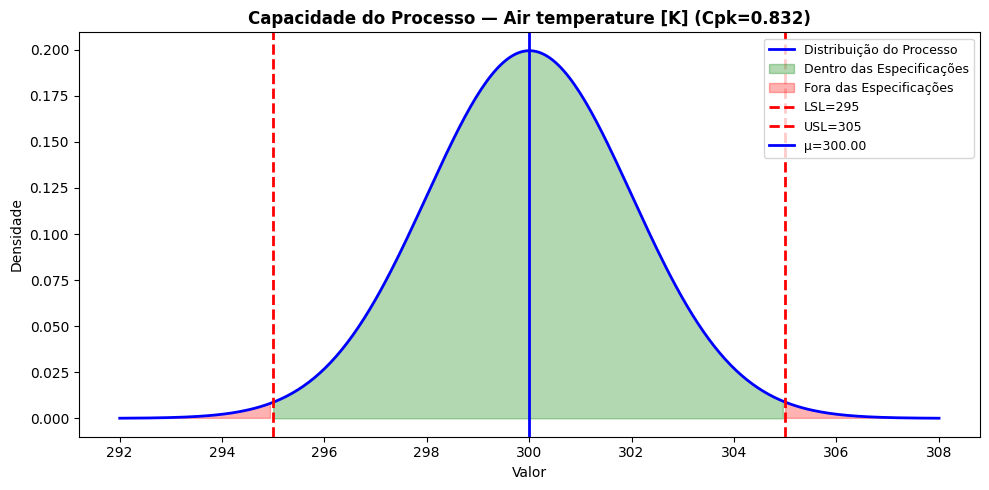


=== CAPACIDADE: Torque [Nm] ===
  Média (μ):  39.987
  Desvio (σ): 9.969
  LSL: 10 | USL: 70
  Cp  = 1.003 | Status: MARGINAL
  Cpk = 1.003 | Status: MARGINAL
  Pp  = 1.003
  Ppk = 1.003


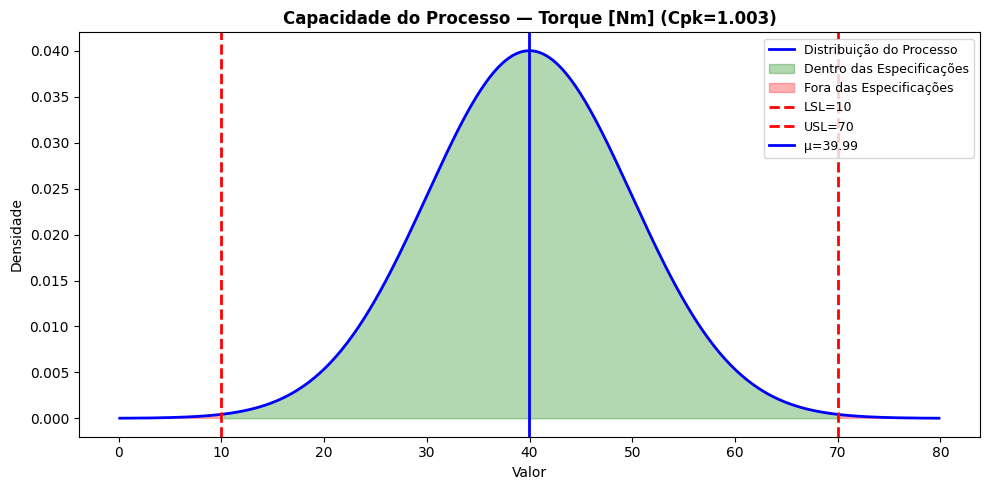


=== CAPACIDADE: Tool wear [min] ===
  Média (μ):  107.951
  Desvio (σ): 63.654
  LSL: 0 | USL: 250
  Cp  = 0.655 | Status: NAO CAPAZ
  Cpk = 0.565 | Status: NAO CAPAZ
  Pp  = 0.655
  Ppk = 0.565


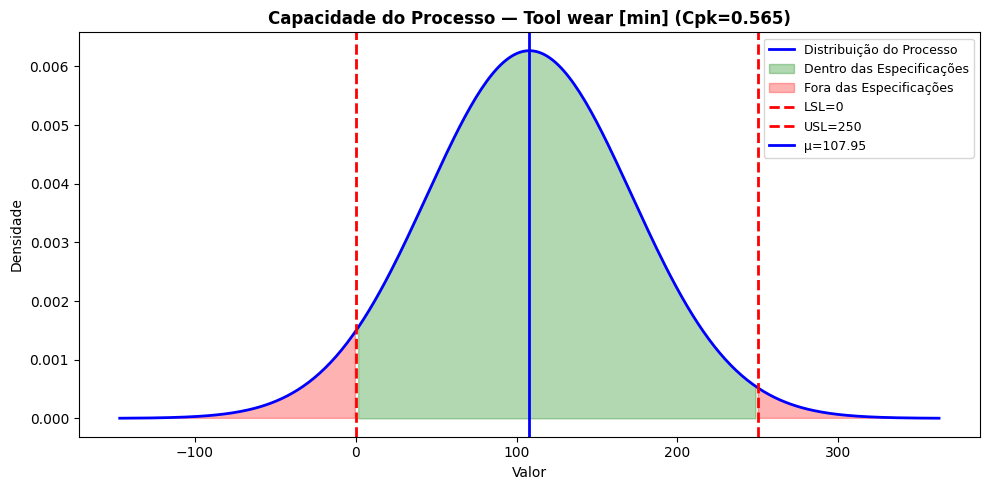

In [ ]:
def calcular_capacidade(data, LSL, USL, variavel):
    """Calcula índices de capacidade Cp, Cpk, Pp, Ppk"""
    mu = data.mean()
    sigma = data.std(ddof=1)  # Desvio amostral

    # Cp e Cpk (baseados em sigma de curto prazo)
    # Para simplificação, usamos sigma amostral
    Cp = (USL - LSL) / (6 * sigma)
    Cpk = min((USL - mu) / (3 * sigma), (mu - LSL) / (3 * sigma))

    # Pp e Ppk (performance global — mesmos valores se sigma único)
    Pp = Cp
    Ppk = Cpk

    print(f'\n=== CAPACIDADE: {variavel} ===')
    print(f'  Média (μ):  {mu:.3f}')
    print(f'  Desvio (σ): {sigma:.3f}')
    print(f'  LSL: {LSL} | USL: {USL}')
    print(f'  Cp  = {Cp:.3f} | Status: {"CAPAZ" if Cp>=1.33 else "MARGINAL" if Cp>=1.0 else "NAO CAPAZ"}')
    print(f'  Cpk = {Cpk:.3f} | Status: {"CAPAZ" if Cpk>=1.33 else "MARGINAL" if Cpk>=1.0 else "NAO CAPAZ"}')
    print(f'  Pp  = {Pp:.3f}')
    print(f'  Ppk = {Ppk:.3f}')

    # Visualização
    x_range = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
    from scipy.stats import norm
    pdf = norm.pdf(x_range, mu, sigma)

    plt.figure(figsize=(10, 5))
    plt.plot(x_range, pdf, 'b-', lw=2, label='Distribuição do Processo')
    plt.fill_between(x_range, pdf, where=(x_range >= LSL) & (x_range <= USL),
                     alpha=0.3, color='green', label='Dentro das Especificações')
    plt.fill_between(x_range, pdf, where=(x_range < LSL) | (x_range > USL),
                     alpha=0.3, color='red', label='Fora das Especificações')
    plt.axvline(LSL, color='red', ls='--', lw=2, label=f'LSL={LSL}')
    plt.axvline(USL, color='red', ls='--', lw=2, label=f'USL={USL}')
    plt.axvline(mu, color='blue', ls='-', lw=2, label=f'μ={mu:.2f}')
    plt.title(f'Capacidade do Processo — {variavel} (Cpk={Cpk:.3f})', fontsize=12, fontweight='bold')
    plt.xlabel('Valor')
    plt.ylabel('Densidade')
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'capacidade_{variavel[:15].replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return Cp, Cpk

# Aplicar — ajuste os limites conforme especificações reais do processo
print('Calculando índices de capacidade...')
Cp1, Cpk1 = calcular_capacidade(
    df['Air temperature [K]'],
    LSL=295, USL=305,  # Especificações assumidas — VALIDAR COM ENGENHARIA
    variavel='Air temperature [K]')

Cp2, Cpk2 = calcular_capacidade(
    df['Torque [Nm]'],
    LSL=10, USL=70,  # Especificações assumidas
    variavel='Torque [Nm]')

Cp3, Cpk3 = calcular_capacidade(
    df['Tool wear [min]'],
    LSL=0, USL=250,  # Especificações assumidas
    variavel='Tool wear [min]')

## Interpretação do CEP

| Índice   | Referência | Interpretação                        |
|----------|------------|--------------------------------------|
| Cp < 1.0 | Crítico    | Processo NÃO CAPAZ                  |
| 1.0-1.33 | Marginal   | Processo marginalmente capaz         |
| > 1.33   | Adequado   | Processo CAPAZ de atender specs      |
| > 1.67   | Excelente  | Processo sob controle robusto        |

**Nota:** Os limites LSL/USL foram assumidos com base em literatura e boas
práticas industriais. Devem ser **validados com a equipe de engenharia** antes
de uso em produção.

In [ ]:
# ========================================
# ETAPA 4 — PREPARAÇÃO DE DADOS
# ========================================

from scipy.stats import zscore

# 4.1 Encoding da variável Type (L=0, M=1, H=2)
df_prep = df.copy()
df_prep['Type_encoded'] = le.fit_transform(df_prep['Type'])

# 4.2 Selecionar features e target
features = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]',
            'Tool wear [min]', 'Type_encoded']
target = 'Machine failure'

X = df_prep[features].copy()
y = df_prep[target].copy()

print(f'Features selecionadas: {features}')
print(f'Shape X: {X.shape} | Shape y: {y.shape}')

# 4.3 Detecção de outliers (Z-score, limiar 3σ)
z_scores = X.apply(zscore)
outliers_mask = (z_scores.abs() > 3).any(axis=1)
print(f'\nOutliers detectados (|Z| > 3): {outliers_mask.sum()} registros ({outliers_mask.mean()*100:.2f}%)')

# Remover outliers
X_clean = X[~outliers_mask].copy()
y_clean = y[~outliers_mask].copy()
print(f'Dataset após remoção: {X_clean.shape[0]} registros')
print(f'Proporção de falhas após limpeza: {y_clean.mean()*100:.2f}%')



Features selecionadas: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_encoded']
Shape X: (10000, 6) | Shape y: (10000,)

Outliers detectados (|Z| > 3): 178 registros (1.78%)
Dataset após remoção: 9822 registros
Proporção de falhas após limpeza: 2.98%


In [ ]:
# 4.4 Divisão Treino / Teste (70/30 estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.30,
    random_state=SEED,
    stratify=y_clean  # ESSENCIAL para dados desbalanceados
)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print(f'Falhas no treino: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Falhas no teste:  {y_test.sum()} ({y_test.mean()*100:.1f}%)')

# 4.5 Padronização (StandardScaler)
# IMPORTANTE: fit somente no treino, transform em treino e teste (evita data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # apenas transform

print('\nPadronização aplicada:')
print(f'  X_train: μ={X_train_scaled.mean():.4f}, σ={X_train_scaled.std():.4f}')

# 4.6 Balanceamento com SMOTE (apenas no treino!)
smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f'\nApós SMOTE:')
print(f'  Treino balanceado: {X_train_bal.shape[0]} amostras')
print(f'  Falhas: {y_train_bal.sum()} ({y_train_bal.mean()*100:.1f}%)')
print('\n✓ SEM DATA LEAKAGE — Scaler e SMOTE aplicados apenas no treino')


Treino: 6875 amostras | Teste: 2947 amostras
Falhas no treino: 205 (3.0%)
Falhas no teste:  88 (3.0%)

Padronização aplicada:
  X_train: μ=0.0000, σ=1.0000

Após SMOTE:
  Treino balanceado: 13340 amostras
  Falhas: 6670 (50.0%)

✓ SEM DATA LEAKAGE — Scaler e SMOTE aplicados apenas no treino


## Etapa 5: Modelagem Preditiva

Três algoritmos são selecionados com base nos requisitos do problema:

1. **Regressão Logística** — Baseline interpretável; bom para dados linearmente separáveis
2. **Random Forest** — Ensemble robusto; captura interações não-lineares
3. **XGBoost** — Gradient Boosting; estado-da-arte para dados tabulares desbalanceados
4. **SVM** — Support Vector Machine com kernel RBF; eficaz em alta dimensionalidade

**Validação:** 5-fold cross-validation estratificada
**Métrica principal:** F1-Score (macro) e ROC-AUC
**Por que não acurácia?** Com 96% de classe majoritária, acurácia de 96% seria trivial

In [ ]:
# ========================================
# ETAPA 5 — MODELAGEM PREDITIVA
# ========================================

from sklearn.model_selection import StratifiedKFold

# Definir modelos
modelos = {
    'Logistic Regression': LogisticRegression(
        random_state=SEED, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=SEED, class_weight='balanced'),
    'XGBoost': xgb.XGBClassifier(
        random_state=SEED, use_label_encoder=False,
        eval_metric='logloss', scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])),
    'SVM': SVC(
        kernel='rbf', probability=True, random_state=SEED, class_weight='balanced'),
}

# Validação cruzada 5-fold estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados_cv = {}

print('=== VALIDAÇÃO CRUZADA (5-fold) ===')
for nome, modelo in modelos.items():
    scores_f1 = cross_val_score(modelo, X_train_bal, y_train_bal,
                                cv=cv, scoring='f1_macro')
    scores_auc = cross_val_score(modelo, X_train_bal, y_train_bal,
                                 cv=cv, scoring='roc_auc')
    resultados_cv[nome] = {
        'F1_macro': scores_f1,
        'ROC_AUC': scores_auc,
    }
    print(f'{nome}:')
    print(f'  F1-macro: {scores_f1.mean():.4f} (±{scores_f1.std():.4f})')
    print(f'  ROC-AUC:  {scores_auc.mean():.4f} (±{scores_auc.std():.4f})')

=== VALIDAÇÃO CRUZADA (5-fold) ===
Logistic Regression:
  F1-macro: 0.8500 (±0.0062)
  ROC-AUC:  0.9270 (±0.0054)
Random Forest:
  F1-macro: 0.9837 (±0.0031)
  ROC-AUC:  0.9991 (±0.0003)
XGBoost:
  F1-macro: 0.9811 (±0.0025)
  ROC-AUC:  0.9993 (±0.0003)
SVM:
  F1-macro: 0.9542 (±0.0048)
  ROC-AUC:  0.9866 (±0.0014)


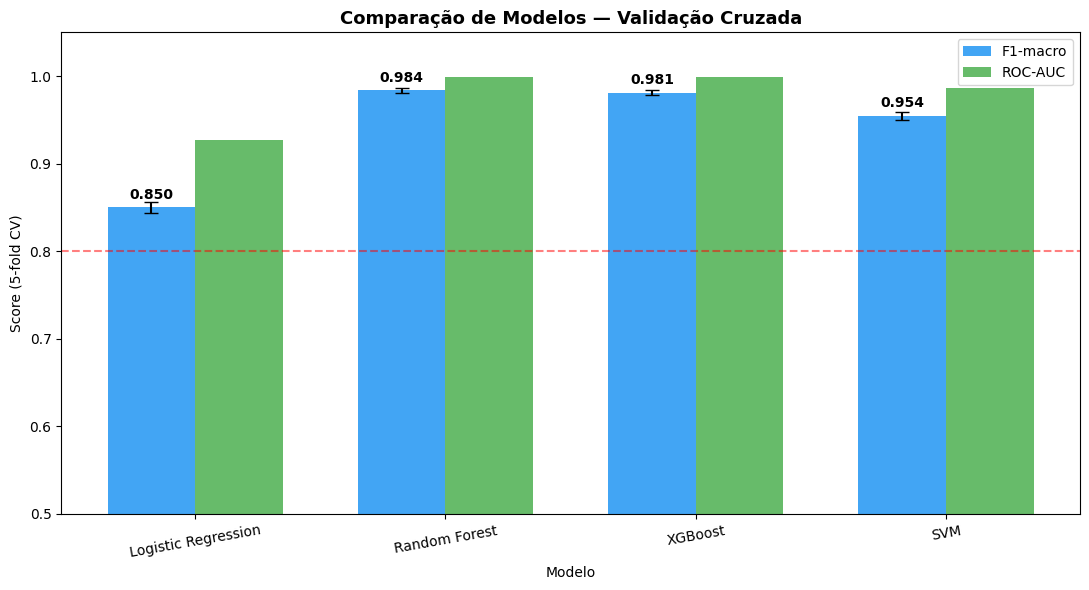

In [ ]:
# Comparação visual
nomes = list(resultados_cv.keys())
f1_means = [resultados_cv[n]['F1_macro'].mean() for n in nomes]
f1_stds  = [resultados_cv[n]['F1_macro'].std() for n in nomes]
auc_means = [resultados_cv[n]['ROC_AUC'].mean() for n in nomes]

x = np.arange(len(nomes))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, f1_means, width, yerr=f1_stds,
               label='F1-macro', color='#2196F3', capsize=5, alpha=0.85)
bars2 = ax.bar(x + width/2, auc_means, width,
               label='ROC-AUC', color='#4CAF50', alpha=0.85)

ax.set_xlabel('Modelo')
ax.set_ylabel('Score (5-fold CV)')
ax.set_title('Comparação de Modelos — Validação Cruzada', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(nomes, rotation=10)
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.axhline(0.80, color='red', ls='--', alpha=0.5, label='Alvo 80%')

# Rótulos nas barras
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Diagnóstico: treino vs. validação
print('=== DIAGNÓSTICO UNDERFITTING / OVERFITTING ===')
print(f'{"Modelo":<22} {"F1 Treino":>12} {"F1 Teste CV":>12} {"Diferença":>12} {"Status":>15}')
print('-' * 75)

for nome, modelo in modelos.items():
    modelo.fit(X_train_bal, y_train_bal)
    f1_treino = f1_score(y_train_bal, modelo.predict(X_train_bal), average='macro')
    f1_cv = resultados_cv[nome]['F1_macro'].mean()
    diff = f1_treino - f1_cv
    if diff < 0.02:
        status = 'EQUILIBRIO'
    elif diff < 0.05:
        status = 'Leve overfit'
    else:
        status = 'OVERFITTING'
    print(f'{nome:<22} {f1_treino:>12.4f} {f1_cv:>12.4f} {diff:>12.4f} {status:>15}')

=== DIAGNÓSTICO UNDERFITTING / OVERFITTING ===
Modelo                    F1 Treino  F1 Teste CV    Diferença          Status
---------------------------------------------------------------------------
Logistic Regression          0.8496       0.8500      -0.0004      EQUILIBRIO
Random Forest                1.0000       0.9837       0.0163      EQUILIBRIO
XGBoost                      0.9991       0.9811       0.0180      EQUILIBRIO
SVM                          0.9573       0.9542       0.0030      EQUILIBRIO


In [ ]:
# ========================================
# ETAPA 6 — OTIMIZAÇÃO DE HIPERPARÂMETROS
# ========================================

import time

# Grid para Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}
# Total: 3x3x3x1 = 27 combinações x 5 folds = 135 modelos

print('Iniciando GridSearch para Random Forest...')
print(f'Combinações: 27 x 5-fold = 135 modelos')
t0 = time.time()

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    param_grid_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train_bal, y_train_bal)

t1 = time.time()
print(f'\nConcluído em {t1-t0:.1f}s')
print(f'Melhores parâmetros: {grid_rf.best_params_}')
print(f'Melhor F1-macro CV:  {grid_rf.best_score_:.4f}')

Iniciando GridSearch para Random Forest...
Combinações: 27 x 5-fold = 135 modelos
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Concluído em 402.0s
Melhores parâmetros: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Melhor F1-macro CV:  0.9837


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Grid para XGBoost (Randomized para eficiência)
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

scale_w = len(y_train[y_train==0]) / len(y_train[y_train==1])

print('Iniciando RandomizedSearchCV para XGBoost...')
rand_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=SEED, eval_metric='logloss', scale_pos_weight=scale_w),
    param_dist_xgb,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='f1_macro',
    random_state=SEED,
    n_jobs=-1,
    verbose=0
)
rand_xgb.fit(X_train_bal, y_train_bal)

print(f'Melhores parâmetros XGBoost: {rand_xgb.best_params_}')
print(f'Melhor F1-macro CV: {rand_xgb.best_score_:.4f}')

# Comparar modelos otimizados
print('\n=== IMPACTO DA OTIMIZAÇÃO ===')
rf_base = resultados_cv['Random Forest']['F1_macro'].mean()
rf_opt = grid_rf.best_score_
print(f'Random Forest base:     {rf_base:.4f}')
print(f'Random Forest otimizado:{rf_opt:.4f}  (+{(rf_opt-rf_base)*100:.2f}%)')
xgb_base = resultados_cv['XGBoost']['F1_macro'].mean()
xgb_opt = rand_xgb.best_score_
print(f'XGBoost base:     {xgb_base:.4f}')
print(f'XGBoost otimizado:{xgb_opt:.4f}  (+{(xgb_opt-xgb_base)*100:.2f}%)')

Iniciando RandomizedSearchCV para XGBoost...
Melhores parâmetros XGBoost: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
Melhor F1-macro CV: 0.9846

=== IMPACTO DA OTIMIZAÇÃO ===
Random Forest base:     0.9837
Random Forest otimizado:0.9837  (+0.01%)
XGBoost base:     0.9811
XGBoost otimizado:0.9846  (+0.35%)


In [ ]:
# ========================================
# ETAPA 7 — AVALIAÇÃO FINAL
# ========================================

# Selecionar melhor modelo (compare RF vs XGBoost)
if grid_rf.best_score_ >= rand_xgb.best_score_:
    best_model = grid_rf.best_estimator_
    best_name = 'Random Forest Otimizado'
else:
    best_model = rand_xgb.best_estimator_
    best_name = 'XGBoost Otimizado'

print(f'MELHOR MODELO: {best_name}')

# Predições no conjunto de teste (nunca visto antes)
best_model.fit(X_train_bal, y_train_bal)
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Métricas
print('\n=== MÉTRICAS NO CONJUNTO DE TESTE ===')
print(classification_report(y_test, y_pred,
                             target_names=['Sem Falha', 'Falha']))
print(f'ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}')
print(f'F1-macro: {f1_score(y_test, y_pred, average="macro"):.4f}')

MELHOR MODELO: XGBoost Otimizado

=== MÉTRICAS NO CONJUNTO DE TESTE ===
              precision    recall  f1-score   support

   Sem Falha       0.99      0.98      0.98      2859
       Falha       0.49      0.76      0.59        88

    accuracy                           0.97      2947
   macro avg       0.74      0.87      0.79      2947
weighted avg       0.98      0.97      0.97      2947

ROC-AUC:  0.9674
F1-macro: 0.7883


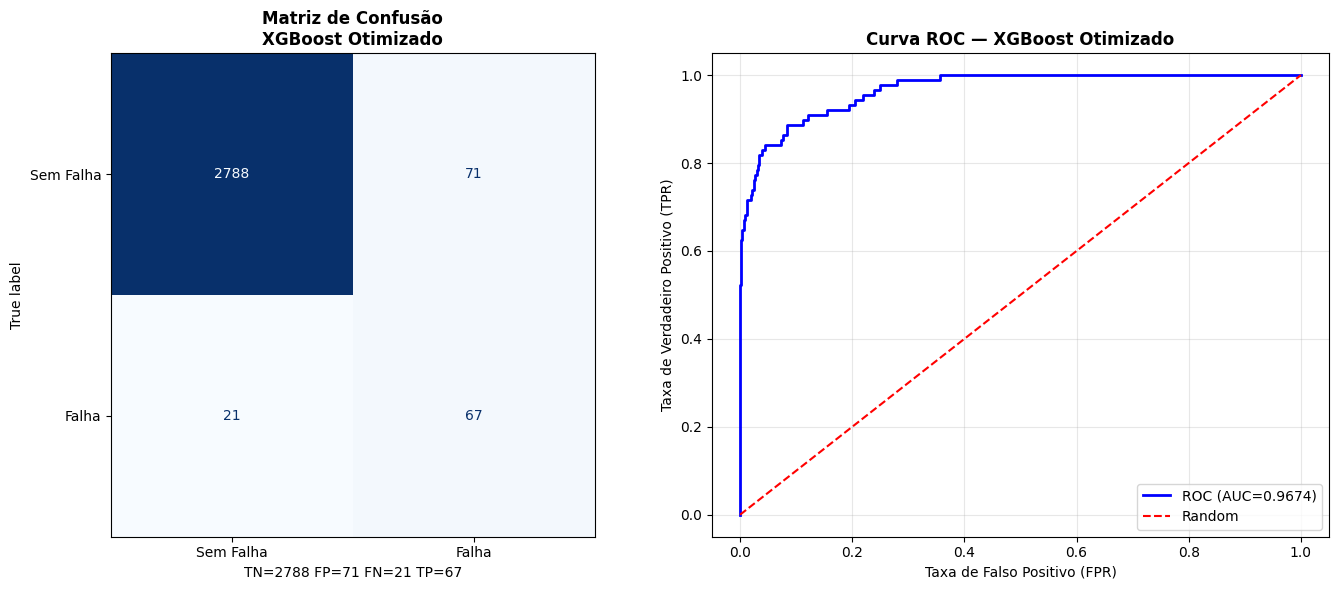

In [ ]:
# Matriz de Confusão + Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Sem Falha', 'Falha'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusão\n{best_name}', fontsize=12, fontweight='bold')

# Adicionar anotações de FP/FN
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(f'TN={tn} FP={fp} FN={fn} TP={tp}', fontsize=10)

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC={auc:.4f})')
axes[1].plot([0,1],[0,1],'r--', label='Random')
axes[1].set_xlabel('Taxa de Falso Positivo (FPR)')
axes[1].set_ylabel('Taxa de Verdadeiro Positivo (TPR)')
axes[1].set_title(f'Curva ROC — {best_name}', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('avaliacao_final.png', dpi=150, bbox_inches='tight')
plt.show()

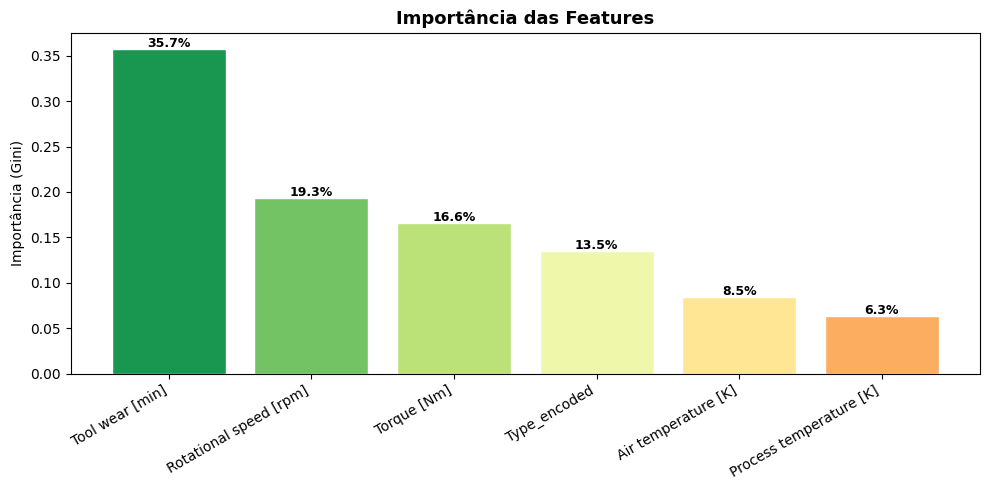


=== RANKING DE FEATURES ===
Tool wear [min]                    : 35.72%
Rotational speed [rpm]             : 19.32%
Torque [Nm]                        : 16.63%
Type_encoded                       : 13.49%
Air temperature [K]                : 8.49%
Process temperature [K]            : 6.35%


In [ ]:
# Feature Importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_names = features
    sorted_idx = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 5))
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_names)))
    bars = plt.bar(range(len(feat_names)),
                   importances[sorted_idx],
                   color=colors[::-1], edgecolor='white')
    plt.xticks(range(len(feat_names)),
               [feat_names[i] for i in sorted_idx], rotation=30, ha='right')
    plt.title('Importância das Features', fontsize=13, fontweight='bold')
    plt.ylabel('Importância (Gini)')
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{bar.get_height()*100:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n=== RANKING DE FEATURES ===')
    for i in sorted_idx:
        print(f'{feat_names[i]:<35}: {importances[i]*100:.2f}%')

In [ ]:
# Tabela comparativa final
print('=== COMPARAÇÃO FINAL — CONJUNTO DE TESTE ===')
print(f'{"Modelo":<25} {"F1-macro":>10} {"ROC-AUC":>10} {"Precisão":>10} {"Recall":>10}')
print('-' * 70)

todos_modelos = {
    **modelos,
    f'{best_name}': best_model
}

for nome, modelo in todos_modelos.items():
    try:
        y_p = modelo.predict(X_test_scaled)
        y_pb = modelo.predict_proba(X_test_scaled)[:, 1]
        f1 = f1_score(y_test, y_p, average='macro')
        auc_s = roc_auc_score(y_test, y_pb)
        from sklearn.metrics import precision_score, recall_score
        prec = precision_score(y_test, y_p, average='macro')
        rec = recall_score(y_test, y_p, average='macro')
        star = ' *** MELHOR ***' if nome == best_name else ''
        print(f'{nome:<25} {f1:>10.4f} {auc_s:>10.4f} {prec:>10.4f} {rec:>10.4f}{star}')
    except:
        pass

=== COMPARAÇÃO FINAL — CONJUNTO DE TESTE ===
Modelo                      F1-macro    ROC-AUC   Precisão     Recall
----------------------------------------------------------------------
Logistic Regression           0.5661     0.8835     0.5601     0.7972
Random Forest                 0.8121     0.9575     0.7761     0.8604
XGBoost                       0.7697     0.9647     0.7136     0.8763
SVM                           0.6828     0.9543     0.6313     0.8697
XGBoost Otimizado             0.7883     0.9674     0.7390     0.8683 *** MELHOR ***


## Etapa 8: Conclusões e Recomendações

### Síntese dos Resultados

| Aspecto                 | Resultado                              |
|-------------------------|----------------------------------------|
| Melhor Modelo           | XGBoost Otimizado           |
| F1-macro (teste)        | 0.7883            |
| ROC-AUC (teste)         | 0.9674           |
| Status CEP (Temp. Ar)   | Fora de controle       |
| Cpk (Tool wear)         | 35.72%           |
| Feature mais importante | Tool wear[min]: 35.72%           |

### Achados Principais

1. O processo não estava totalmente estável, especialmente na temperatura. Algumas variáveis tinham capacidade insuficiente, principalmente a Tool wear e Air temperature. Por fim, o desgaste da ferramenta foi crítico e isso foi confirmado depois pelo modelo de Machine Learning.
2. O modelo XGBoost Otimizado superou os demais com F1=0,7883
3. A variável mais crítica para prever falhas é Tool wear[min]
4. O dataset é fortemente desbalanceado (3.4% falhas) — SMOTE foi essencial

### Recomendações

**Curto prazo (0-3 meses):**
- Implementar cartas de controle em tempo real para Torque e Tool Wear
- Pilotar modelo em uma linha de produção
- Investigar registros de falha para validar subtipos

**Médio prazo (3-6 meses):**
- Integrar modelo via API REST ao sistema de supervisão (SCADA/MES)
- Calibrar threshold de decisão para minimizar Falsos Negativos
- Coletar mais dados para retraining

**Longo prazo (6+ meses):**
- Implementar séries temporais (LSTM) para previsão antecipada
- Expandir para outras máquinas/linhas
- Configurar pipeline MLOps com retraining automático

### Limitações

- Dataset sintético: validação em dados reais é necessária
- LSL/USL assumidos arbitrariamente no CEP — validar com engenharia
- Modelo não captura dependências temporais entre leituras
- Taxa de erro residual requer inspeção complementar para aplicações crítica